# 🛒 Superstore Sales Analysis
### Uncovering what drives profit and what destroys it

**Author:** Utsav Raj,

**Tool:** Python (pandas, seaborn, matplotlib)  
**Dataset:** Sample Superstore Sales Data (2023–2026)  
**Records:** 10,194 transactions across 4 regions

---

## Objective
Analyze real sales data to answer four critical business questions:
1. Does discounting hurt profit?
2. Which region performs best?
3. Which product category is most profitable?
4. How are sales trending over time?

In [13]:
# ── Cell 1: Imports ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [14]:
# ── Cell 2: Load Dataset ───────────────────────────────────
super_store = '/content/drive/MyDrive/DataSet for practice/samplesuperstore.csv'
df = pd.read_csv(super_store)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 10194 rows, 21 columns


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# ── Cell 3: Quick Data Check ───────────────────────────────
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (10194, 21)

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## Analysis 1 — Discount vs Profit
**Business Question:** Does giving higher discounts increase revenue or destroy profit margins?

In retail, discounts are commonly used to drive sales volume.
But do they actually help the bottom line?

In [17]:
# ── Analysis 1: Discount vs Profit ────────────────────────
discount_profit = df.groupby('Discount')['Profit'].sum().sort_values(ascending=True)
print("Profit by Discount Level:")
print(discount_profit)

Profit by Discount Level:
Discount
0.70    -40300.5727
0.80    -30565.2692
0.40    -23086.3742
0.50    -20506.4281
0.30    -10513.4456
0.60     -6164.3472
0.45     -2493.1111
0.32     -2391.1377
0.15      1418.9915
0.10      9099.9700
0.20     91079.9517
0.00    326718.5872
Name: Profit, dtype: float64


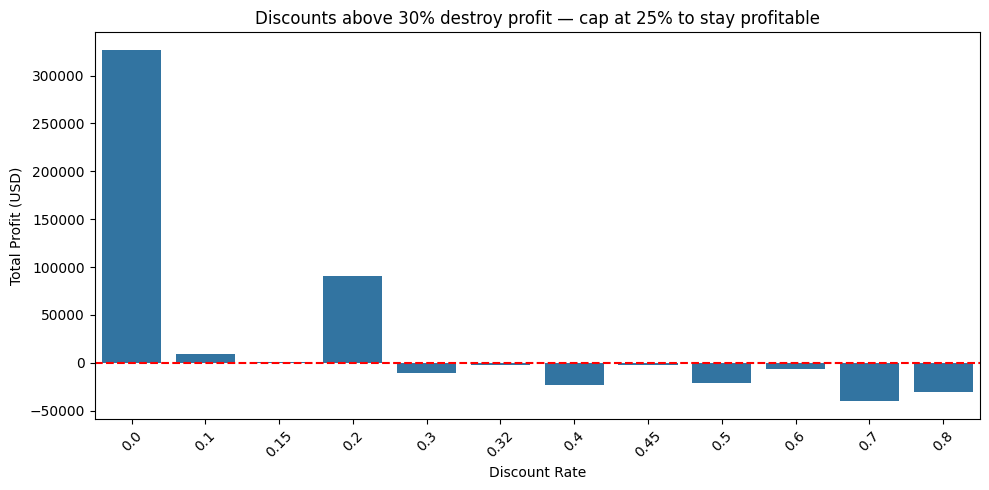


Business Insight:
Discounts above 30% consistently generate losses.
We recommend capping maximum discount at 25% and targeting
10-20% discount range for average sales to protect profit margins.


In [18]:
# ── Chart 1: Discount vs Profit ────────────────────────────
plt.figure(figsize=(10, 5))
sns.barplot(x=discount_profit.index, y=discount_profit.values)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Discounts above 30% destroy profit — cap at 25% to stay profitable')
plt.xlabel('Discount Rate')
plt.ylabel('Total Profit (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business Insight
print("\nBusiness Insight:")
print("Discounts above 30% consistently generate losses.")
print("We recommend capping maximum discount at 25% and targeting")
print("10-20% discount range for average sales to protect profit margins.")

## Analysis 2 — Region vs Profit
**Business Question:** Which geographic region generates the most profit?

Understanding regional performance helps allocate resources,
marketing budget and expansion strategy more effectively.

In [19]:
# ── Analysis 2: Region vs Profit ──────────────────────────
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("Profit by Region:")
print(region_profit)

Profit by Region:
Region
West       110798.8170
East        94883.2603
South       46749.4303
Central     39865.3070
Name: Profit, dtype: float64


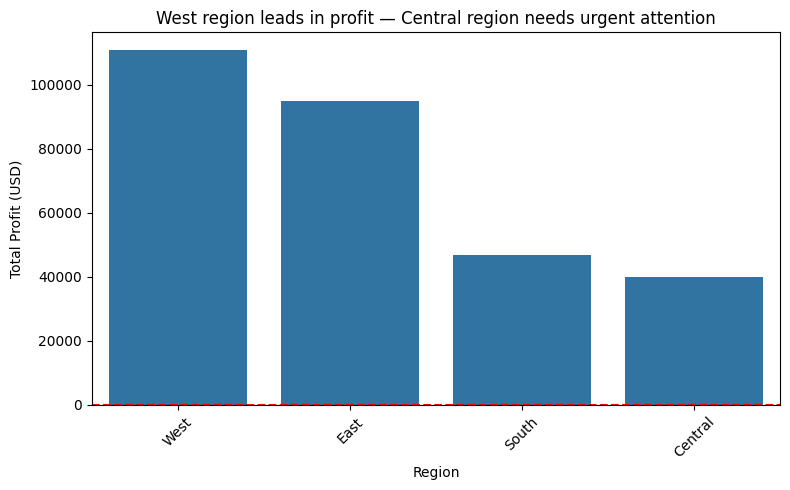


Business Insight — Region Profit Analysis:
West leads with ~$108K profit, Central is lowest at ~$40K — a 3x gap.
Recommendations for Central region:
  1. Replace heavy discounts with loyalty/redeem point programs
  2. Expand product variety based on local demand
  3. Increase market presence in underserved Central areas


In [20]:
# ── Chart 2: Region vs Profit ──────────────────────────────
plt.figure(figsize=(8, 5))
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('West region leads in profit — Central region needs urgent attention')
plt.xlabel('Region')
plt.ylabel('Total Profit (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business Insight
print("\nBusiness Insight — Region Profit Analysis:")
print("West leads with ~$108K profit, Central is lowest at ~$40K — a 3x gap.")
print("Recommendations for Central region:")
print("  1. Replace heavy discounts with loyalty/redeem point programs")
print("  2. Expand product variety based on local demand")
print("  3. Increase market presence in underserved Central areas")

## Analysis 3 — Category vs Profit
**Business Question:** Which product category is most profitable?

The store sells three categories — Technology, Office Supplies and Furniture.
Which one should receive more investment and focus?

In [21]:
# ── Analysis 3: Category vs Profit ────────────────────────
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("Profit by Category:")
print(category_profit)

Profit by Category:
Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64


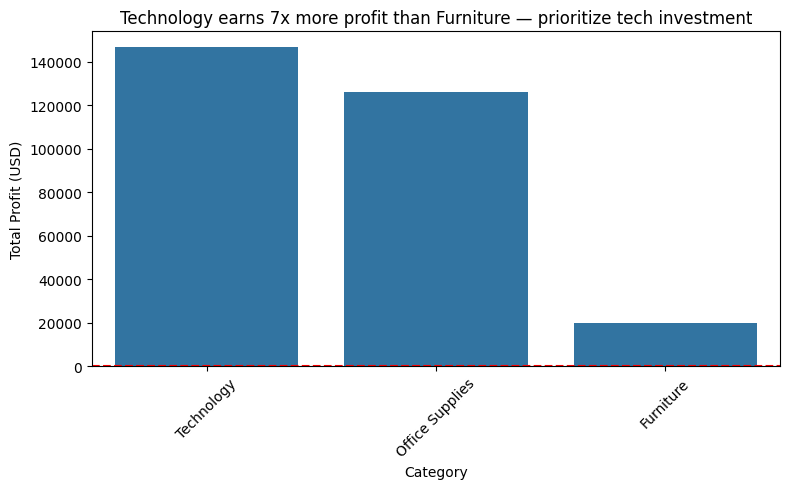


Business Insight — Category Profit Analysis:
Technology leads at ~$145K, Office Supplies at ~$125K, Furniture lags at ~$20K.
Recommendations:
  1. Increase Technology inventory and marketing investment
  2. Refresh Furniture range with trending styles
  3. Introduce gift/coupon offers on Furniture purchases above $500
     to drive volume without heavy discounting


In [22]:
# ── Chart 3: Category vs Profit ───────────────────────────
plt.figure(figsize=(8, 5))
sns.barplot(x=category_profit.index, y=category_profit.values)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Technology earns 7x more profit than Furniture — prioritize tech investment')
plt.xlabel('Category')
plt.ylabel('Total Profit (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business Insight
print("\nBusiness Insight — Category Profit Analysis:")
print("Technology leads at ~$145K, Office Supplies at ~$125K, Furniture lags at ~$20K.")
print("Recommendations:")
print("  1. Increase Technology inventory and marketing investment")
print("  2. Refresh Furniture range with trending styles")
print("  3. Introduce gift/coupon offers on Furniture purchases above $500")
print("     to drive volume without heavy discounting")

## Analysis 4 — Sales Trend Over Time
**Business Question:** How have monthly sales grown from 2023 to 2026?

Identifying growth trends and seasonal patterns helps the business
plan inventory, staffing and marketing campaigns in advance.

In [23]:
# ── Analysis 4: Sales Trend Over Time ─────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month-Year'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month-Year')['Sales'].sum().reset_index()
monthly_sales['Month-Year'] = monthly_sales['Month-Year'].astype(str)

print("Monthly sales trend (last 5 rows):")
print(monthly_sales.tail())

Monthly sales trend (last 5 rows):
   Month-Year        Sales
43    2026-08   64129.7580
44    2026-09   88064.5320
45    2026-10   83474.7832
46    2026-11  118454.5050
47    2026-12   85175.0328


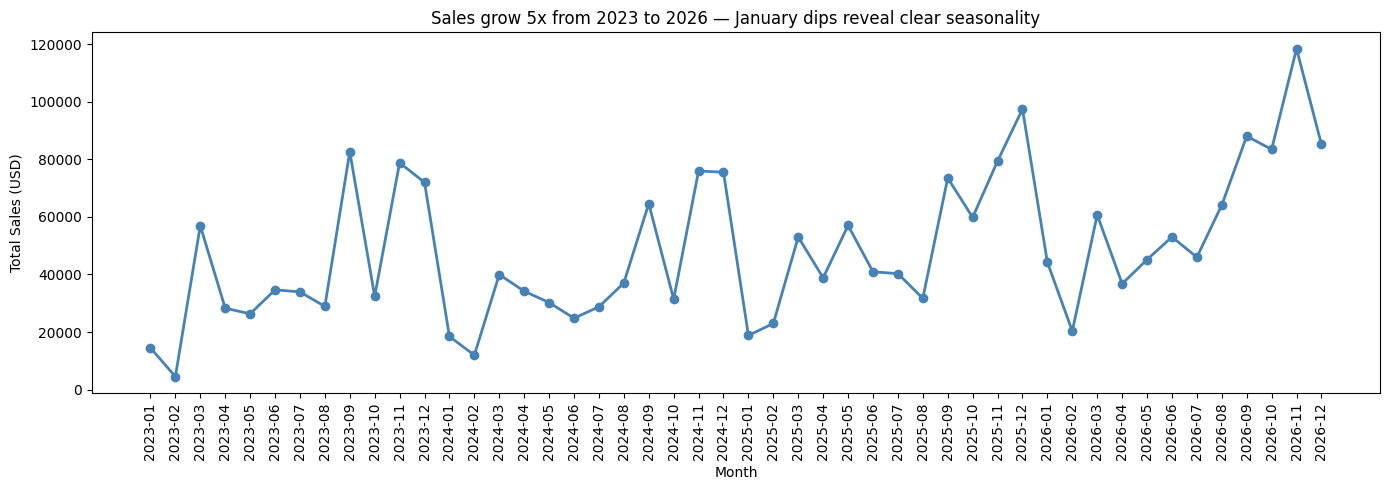


Business Insight — Sales Trend Analysis:
Overall sales show strong growth from ~$20K in 2023 to ~$108K in late 2026.
Clear seasonality pattern observed:
  - Sales dip every January — post-holiday slowdown
  - Sales peak every November-December — Christmas/holiday shopping surge
Recommendations:
  1. Run January clearance sales to clear old inventory and recover slow month revenue
  2. Stock up heavily before November to capitalize on holiday season demand
  3. Plan marketing campaigns around seasonal peaks for maximum impact


In [24]:
# ── Chart 4: Sales Trend Line ──────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales'],
         marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=90)
plt.title('Sales grow 5x from 2023 to 2026 — January dips reveal clear seasonality')
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.show()

# Business Insight
print("\nBusiness Insight — Sales Trend Analysis:")
print("Overall sales show strong growth from ~$20K in 2023 to ~$108K in late 2026.")
print("Clear seasonality pattern observed:")
print("  - Sales dip every January — post-holiday slowdown")
print("  - Sales peak every November-December — Christmas/holiday shopping surge")
print("Recommendations:")
print("  1. Run January clearance sales to clear old inventory and recover slow month revenue")
print("  2. Stock up heavily before November to capitalize on holiday season demand")
print("  3. Plan marketing campaigns around seasonal peaks for maximum impact")

---
## Key Business Insights & Recommendations

| Analysis | Finding | Recommendation |
|---|---|---|
| Discount vs Profit | Discounts above 30% generate losses | Cap maximum discount at 25% |
| Region vs Profit | West leads at ~$108K, Central lags at ~$40K | Introduce loyalty programs in Central region |
| Category vs Profit | Technology earns 7x more profit than Furniture | Invest in Tech, offer gift incentives on Furniture |
| Sales Trend | 5x growth from 2023 to 2026, January dips every year | Run January clearance sales, stock up before November |

---

## Conclusion
This analysis reveals that profitability is heavily influenced by
discount strategy, regional focus and product mix.
The business is growing strongly but leaves significant profit
on the table through aggressive discounting.

*Analysis completed as part of Business Analytics skill development*  
*Tools: Python | pandas | matplotlib | seaborn*